# CFM Volatility Forecasting — Notebook principal

**Auteur** : Adam Kerouredan
**Référence** : G. Paleologo, *The Elements of Quantitative Investing*, Wiley 2024.

Ce notebook orchestre les phases du projet :
- **Phase I** — Ingestion + EDA
- **Phase II** — Feature Engineering + évaluation
- **Phase III** — Neutralisation cross-sectionnelle (préparation à la modélisation)

---

## PHASE I — Ingestion et Analyse Exploratoire

### 1. Chargement des données

In [1]:
import sys
sys.path.append("../")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import DataLoader

loader = DataLoader(data_dir="../data/")
x_train, y_train, x_test = loader.load_all()

print(f"x_train : {x_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"x_test  : {x_test.shape}")

[WARNING] x_train contient 839634 valeurs manquantes.
[WARNING] x_test contient 875392 valeurs manquantes.
x_train : (636313, 111)
y_train : (636313, 2)
x_test  : (635397, 111)


### 2. EDA — analyse exploratoire complète

DESCRIPTION DU DATASET
  Lignes totales        :    636,313
  Colonnes totales      :        111
  Stocks uniques        :        318
  Jours uniques         :      2,117
  Colonnes volatilité   :         54
  Colonnes return dir.  :         54

VALEURS MANQUANTES
  Lignes avec au moins 1 NaN : 99,701 (15.7%)
  NaN moyen par ligne        : 0.66
  Max NaN sur une ligne      : 53


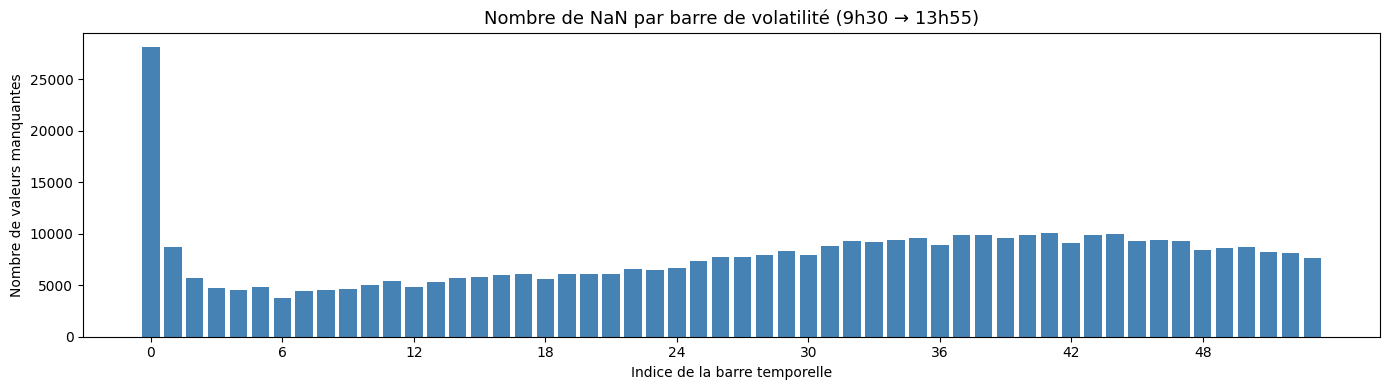


DISTRIBUTION DE LA TARGET (vol 14h-16h)
count    636313.000000
mean          0.183569
std           0.155562
min           0.000132
25%           0.098403
50%           0.141679
75%           0.214632
max           7.581517

  Skewness  : 5.014
  Kurtosis  : 59.902


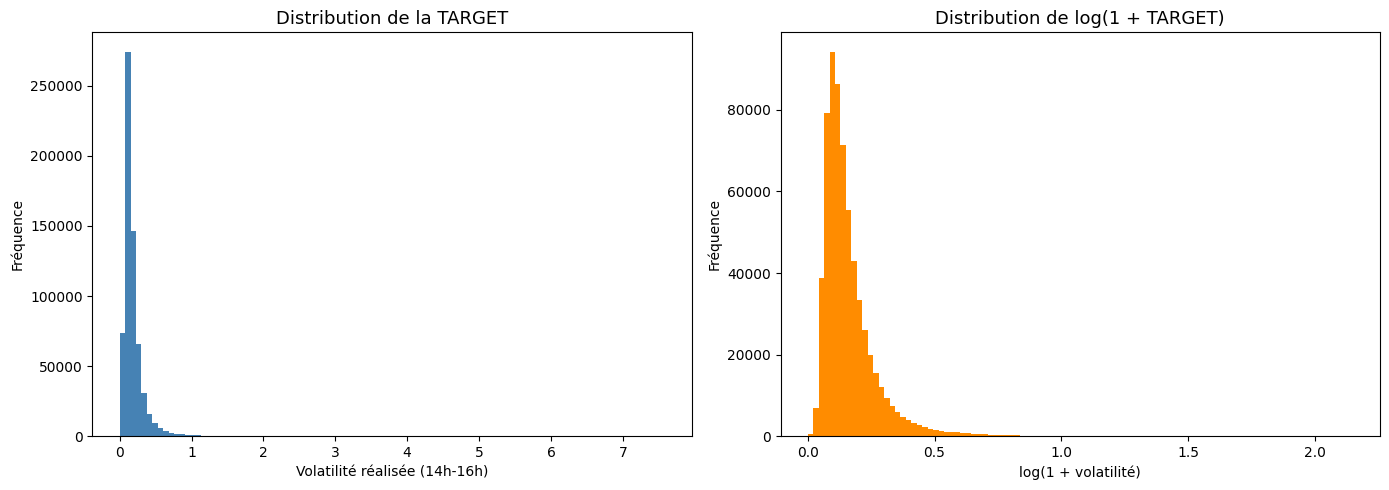


PERSISTANCE DE LA VOLATILITÉ
  Corrélation vol matin / TARGET : 0.8573


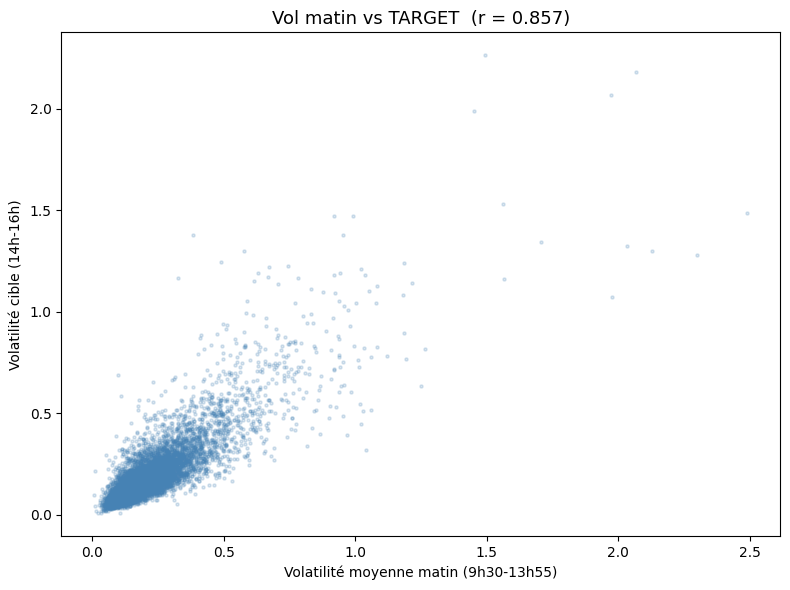

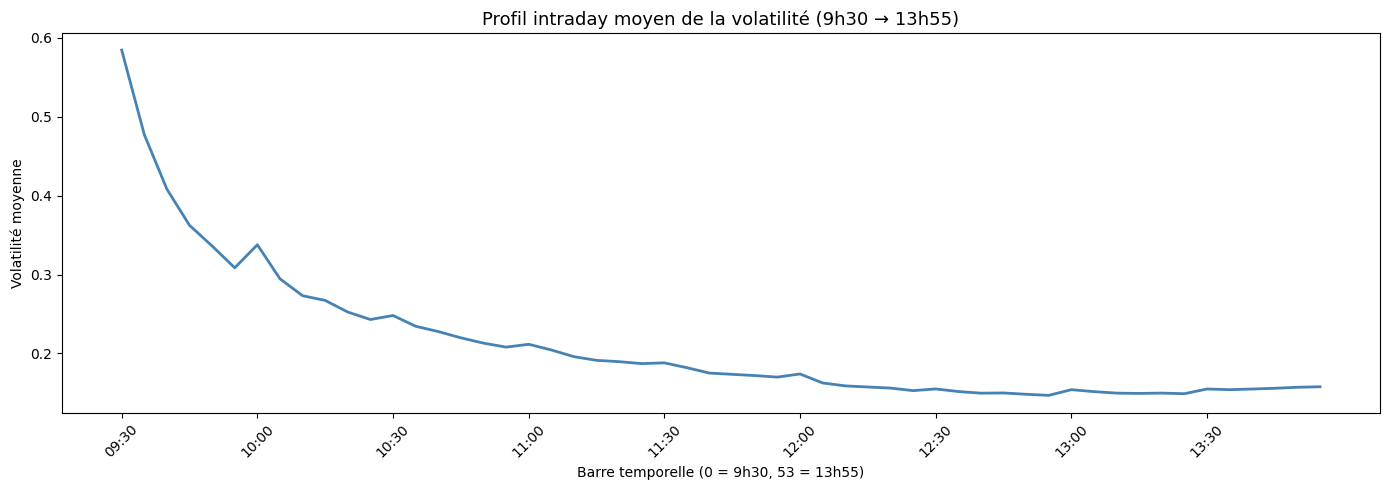

In [2]:
from src.eda_analyzer import EDAAnalyzer

eda = EDAAnalyzer(x_train, y_train, output_dir="../outputs/")
eda.run()

### 3. EDA complémentaire — structure des NaN et profil intraday

In [3]:
# NaN par barre temporelle
missing_per_col = x_train[eda.volatility_columns].isnull().sum()
print("5 premières barres:")
print(missing_per_col.head().to_string())
print("\n5 dernières barres:")
print(missing_per_col.tail().to_string())

# Profil intraday
mean_by_bar = x_train[eda.volatility_columns].mean()
print("\nVol moyenne toutes les 6 barres:")
print(mean_by_bar.iloc[::6].to_string())

5 premières barres:
volatility 09:30:00    28091
volatility 09:35:00     8755
volatility 09:40:00     5657
volatility 09:45:00     4756
volatility 09:50:00     4536

5 dernières barres:
volatility 13:35:00    8606
volatility 13:40:00    8746
volatility 13:45:00    8230
volatility 13:50:00    8166
volatility 13:55:00    7671

Vol moyenne toutes les 6 barres:
volatility 09:30:00    0.584382
volatility 10:00:00    0.337733
volatility 10:30:00    0.248104
volatility 11:00:00    0.211613
volatility 11:30:00    0.188078
volatility 12:00:00    0.173996
volatility 12:30:00    0.155027
volatility 13:00:00    0.154092
volatility 13:30:00    0.154943


### 4. Distribution de la TARGET — détection des outliers

In [4]:
target = y_train["TARGET"]

p995 = np.percentile(target, 99.5)
p999 = np.percentile(target, 99.9)
p100 = target.max()

print(f"99.5e percentile : {p995:.4f}")
print(f"99.9e percentile : {p999:.4f}")
print(f"Maximum          : {p100:.4f}")
print(f"Valeurs > 99.5p  : {(target > p995).sum()}")
print(f"Valeurs > 99.9p  : {(target > p999).sum()}")

99.5e percentile : 1.0225
99.9e percentile : 1.5931
Maximum          : 7.5815
Valeurs > 99.5p  : 3182
Valeurs > 99.9p  : 637


---

## PHASE II — Feature Engineering

### 5. Construction des features
- Imputation : interpolation linéaire intraday + ffill + bfill
- 10 features finales après suppression des redondances

In [5]:
from src.feature_engineer import FeatureEngineer

engineer = FeatureEngineer(x_train, x_test)
features_train, features_test = engineer.build()

print(f"features_train : {features_train.shape}")
print(f"features_test  : {features_test.shape}")
print(f"\nFeatures retenues :")
for col in [c for c in features_train.columns if c != "ID"]:
    print(f"  {col}")

features_train : (636313, 11)
features_test  : (635397, 11)

Features retenues :
  vol_mean
  vol_mean_minus_median
  vol_mean_recent
  vol_last_bar
  vol_linear_slope
  vol_std
  vol_min
  vol_recent_over_mean
  return_n_positive
  return_n_negative


### 6. Vérifications post-engineering

In [6]:
# Shapes, NaN résiduels, alignement ID
print("=== NaN RÉSIDUELS ===")
print(f"features_train : {features_train.isnull().sum().sum()}")
print(f"features_test  : {features_test.isnull().sum().sum()}")

print("\n=== ALIGNEMENT ID ===")
aligned = (features_train["ID"].values == y_train["ID"].values).all()
print(f"features_train['ID'] == y_train['ID'] : {aligned}")

print("\n=== STATS DESCRIPTIVES ===")
feature_cols = [c for c in features_train.columns if c != "ID"]
print(features_train[feature_cols].describe().round(4).to_string())

=== NaN RÉSIDUELS ===
features_train : 0
features_test  : 0

=== ALIGNEMENT ID ===
features_train['ID'] == y_train['ID'] : True

=== STATS DESCRIPTIVES ===
          vol_mean  vol_mean_minus_median  vol_mean_recent  vol_last_bar  vol_linear_slope      vol_std      vol_min  vol_recent_over_mean  return_n_positive  return_n_negative
count  636313.0000            636313.0000      636313.0000   636313.0000       636313.0000  636313.0000  636313.0000           636313.0000        636313.0000        636313.0000
mean        0.2108                 0.0508           0.1548        0.1568           -0.0045       0.1827       0.0206                0.7188            22.9775            23.0684
std         0.1499                 0.0442           0.1497        0.1990            0.0042       0.1337       0.0318                0.3113             5.0431             5.1507
min         0.0001                -0.7676           0.0000        0.0000           -0.2451       0.0000       0.0000                0.00

---

## PHASE II — Évaluation des features

### 7. Information Coefficient — Pearson, Kendall tau, cross-sectionnel

In [7]:
from scipy.stats import spearmanr, kendalltau

target_log = np.log(y_train["TARGET"].values)
feature_cols = [c for c in features_train.columns if c != "ID"]

# --- IC Pearson ---
print("=" * 60)
print("IC PEARSON vs log(TARGET)")
print("=" * 60)
ic_pearson = {}
for col in feature_cols:
    r = np.corrcoef(features_train[col], target_log)[0, 1]
    ic_pearson[col] = r

for name, r in sorted(ic_pearson.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:<30} : {r:+.4f}")

# --- IC Kendall tau (rangs, robuste outliers) ---
print("\n" + "=" * 60)
print("IC KENDALL TAU vs log(TARGET)")
print("=" * 60)
ic_kendall = {}
for col in feature_cols:
    tau, pval = kendalltau(features_train[col].values, target_log)
    ic_kendall[col] = (tau, pval)

print(f"  {'Feature':<30} {'Kendall tau':>12} {'p-value':>12}")
for name, (tau, pval) in sorted(ic_kendall.items(), key=lambda x: abs(x[1][0]), reverse=True):
    print(f"  {name:<30} {tau:>+12.4f} {pval:>12.2e}")

IC PEARSON vs log(TARGET)
  vol_mean                       : +0.7682
  vol_mean_recent                : +0.6777
  vol_std                        : +0.6533
  vol_min                        : +0.5621
  vol_last_bar                   : +0.5342
  vol_mean_minus_median          : +0.5191
  vol_linear_slope               : -0.4211
  return_n_negative              : +0.2116
  vol_recent_over_mean           : +0.1918
  return_n_positive              : +0.1490

IC KENDALL TAU vs log(TARGET)
  Feature                         Kendall tau      p-value
  vol_mean                            +0.6287     0.00e+00
  vol_mean_recent                     +0.5518     0.00e+00
  vol_std                             +0.5170     0.00e+00
  vol_last_bar                        +0.3678     0.00e+00
  vol_mean_minus_median               +0.3571     0.00e+00
  vol_min                             +0.3372     0.00e+00
  vol_linear_slope                    -0.2707     0.00e+00
  return_n_negative                   +0.

### 8. Matrice de corrélation rankée + IC cross-sectionnel

In [8]:
# --- Matrice Spearman entre features ---
print("=" * 60)
print("MATRICE SPEARMAN ENTRE FEATURES")
print("=" * 60)
X = features_train[feature_cols].values

spearman_matrix = np.zeros((len(feature_cols), len(feature_cols)))
for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        r, _ = spearmanr(X[:, i], X[:, j])
        spearman_matrix[i, j] = r

df_spearman = pd.DataFrame(
    spearman_matrix, index=feature_cols, columns=feature_cols
)
print(df_spearman.round(3).to_string())

# --- IC cross-sectionnel ---
print("\n" + "=" * 60)
print("IC CROSS-SECTIONNEL MOYEN (Spearman par date)")
print("=" * 60)

features_with_date = features_train.copy()
features_with_date["date"]       = x_train["date"].values
features_with_date["target_log"] = target_log

cross_section_ics = {col: [] for col in feature_cols}
dates = features_with_date["date"].unique()

for date in dates:
    mask   = features_with_date["date"] == date
    subset = features_with_date[mask]
    if len(subset) < 10:
        continue
    for col in feature_cols:
        r, _ = spearmanr(subset[col].values, subset["target_log"].values)
        if not np.isnan(r):
            cross_section_ics[col].append(r)

print(f"  {'Feature':<30} {'IC moyen':>10} {'IC std':>10} {'t-stat':>10}")
for col in feature_cols:
    ics    = np.array(cross_section_ics[col])
    ic_m   = ics.mean()
    ic_s   = ics.std()
    t_stat = ic_m / (ic_s / np.sqrt(len(ics))) if ic_s > 0 else 0
    print(f"  {col:<30} {ic_m:>+10.4f} {ic_s:>10.4f} {t_stat:>+10.2f}")

MATRICE SPEARMAN ENTRE FEATURES
                       vol_mean  vol_mean_minus_median  vol_mean_recent  vol_last_bar  vol_linear_slope  vol_std  vol_min  vol_recent_over_mean  return_n_positive  return_n_negative
vol_mean                  1.000                  0.644            0.792         0.543            -0.609    0.879    0.537                 0.078              0.226              0.267
vol_mean_minus_median     0.644                  1.000            0.425         0.278            -0.626    0.822    0.219                -0.109              0.036              0.042
vol_mean_recent           0.792                  0.425            1.000         0.673            -0.240    0.631    0.490                 0.625              0.196              0.256
vol_last_bar              0.543                  0.278            0.673         1.000            -0.175    0.418    0.383                 0.421              0.164              0.215
vol_linear_slope         -0.609                 -0.626    

### 9. Diagnostic Marchenko-Pastur — composantes réelles

Détermine combien de composantes principales contiennent un vrai signal,
au-dessus du bruit d'estimation théorique.

In [9]:
from sklearn.preprocessing import StandardScaler

# Ratio dimensions / observations
p     = len(feature_cols)
n     = len(features_train)
gamma = p / n

# Bornes Marchenko-Pastur (variance unitaire après StandardScaler)
sigma2       = 1.0
lambda_plus  = sigma2 * (1 + np.sqrt(gamma)) ** 2
lambda_minus = sigma2 * (1 - np.sqrt(gamma)) ** 2

print(f"p (features)     : {p}")
print(f"n (observations) : {n:,}")
print(f"gamma            : {gamma:.6f}")
print(f"lambda_+         : {lambda_plus:.6f}")
print(f"lambda_-         : {lambda_minus:.6f}")

# Calcul des valeurs propres empiriques
X_scaled    = StandardScaler().fit_transform(features_train[feature_cols])
cov_matrix  = np.cov(X_scaled.T)
eigenvalues = np.linalg.eigvalsh(cov_matrix)[::-1]

print("\nValeurs propres empiriques vs bord MP :")
n_signal = 0
for i, ev in enumerate(eigenvalues):
    flag = "SIGNAL" if ev > lambda_plus else "BRUIT"
    if ev > lambda_plus:
        n_signal += 1
    print(f"  PC{i+1:2d} : {ev:.4f}  → {flag}")

print(f"\n=> {n_signal} composantes au-dessus du bruit (MP)")

p (features)     : 10
n (observations) : 636,313
gamma            : 0.000016
lambda_+         : 1.007944
lambda_-         : 0.992087

Valeurs propres empiriques vs bord MP :
  PC 1 : 4.7474  → SIGNAL
  PC 2 : 1.6811  → SIGNAL
  PC 3 : 1.1637  → SIGNAL
  PC 4 : 0.9397  → BRUIT
  PC 5 : 0.5075  → BRUIT
  PC 6 : 0.4097  → BRUIT
  PC 7 : 0.2742  → BRUIT
  PC 8 : 0.1858  → BRUIT
  PC 9 : 0.0558  → BRUIT
  PC10 : 0.0350  → BRUIT

=> 3 composantes au-dessus du bruit (MP)


---

## PHASE III — Neutralisation cross-sectionnelle

### 10. Retrait de la composante systématique

Pour chaque date $t$, on soustrait la moyenne cross-sectionnelle des features
et de la target :
$$\tilde{f}_{i,t} = f_{i,t} - \frac{1}{N_t}\sum_j f_{j,t}$$

Cette opération isole la composante idiosyncratique du signal.

In [10]:
from src.neutralizer import Neutralizer

neutralizer = Neutralizer(date_column="date")

# Neutralisation features et target
features_train_neutral = neutralizer.neutralize_features(features_train, x_train)
target_log_series      = pd.Series(np.log(y_train["TARGET"].values))
target_log_neutral     = neutralizer.neutralize_target(target_log_series, x_train)

print("=== APRÈS NEUTRALISATION ===")
print(f"features shape   : {features_train_neutral.shape}")
print(f"target shape     : {target_log_neutral.shape}")
print(f"target mean      : {target_log_neutral.mean():.6f}  (attendu ~ 0)")
print(f"target std       : {target_log_neutral.std():.4f}")

print("\n=== STATS FEATURES NEUTRALISÉES ===")
print(
    features_train_neutral
    .drop(columns=["ID"])
    .describe()
    .round(4)
    .to_string()
)

=== APRÈS NEUTRALISATION ===
features shape   : (636313, 11)
target shape     : (636313,)
target mean      : -0.000000  (attendu ~ 0)
target std       : 0.3941

=== STATS FEATURES NEUTRALISÉES ===
          vol_mean  vol_mean_minus_median  vol_mean_recent  vol_last_bar  vol_linear_slope      vol_std      vol_min  vol_recent_over_mean  return_n_positive  return_n_negative
count  636313.0000            636313.0000      636313.0000   636313.0000       636313.0000  636313.0000  636313.0000           636313.0000        636313.0000        636313.0000
mean        0.0000                 0.0000           0.0000       -0.0000            0.0000       0.0000      -0.0000               -0.0000            -0.0000             0.0000
std         0.1068                 0.0376           0.1072        0.1592            0.0036       0.1054       0.0236                0.2836             4.6807             4.6930
min        -1.0800                -0.8741          -1.7282       -2.0100           -0.2203     

### 11. Comparaison IC bruts vs IC neutralisés

Si l'IC chute fortement après neutralisation → le signal était dominé par la
composante systématique (beta marché).
Si l'IC reste stable → signal idiosyncratique réel.

In [14]:
# IC sur target neutralisée
target_neutral_array = target_log_neutral.values

print(f"  {'Feature':<30} {'IC brut':>10} {'IC neutralisé':>14} {'Δ':>8}")
print("  " + "-" * 65)

for col in feature_cols:
    r_brut    = ic_pearson[col]
    feat_neut = features_train_neutral[col].values
    r_neut    = np.corrcoef(feat_neut, target_neutral_array)[0, 1]
    delta     = r_neut - r_brut
    print(f"  {col:<30} {r_brut:>+10.4f} {r_neut:>+14.4f} {delta:>+8.4f}")

  Feature                           IC brut  IC neutralisé        Δ
  -----------------------------------------------------------------
  vol_mean                          +0.7682        +0.6638  -0.1044
  vol_mean_minus_median             +0.5191        +0.3626  -0.1565
  vol_mean_recent                   +0.6777        +0.5390  -0.1387
  vol_last_bar                      +0.5342        +0.3733  -0.1609
  vol_linear_slope                  -0.4211        -0.3440  +0.0771
  vol_std                           +0.6533        +0.5120  -0.1412
  vol_min                           +0.5621        +0.4110  -0.1512
  vol_recent_over_mean              +0.1918        +0.0923  -0.0995
  return_n_positive                 +0.1490        +0.1867  +0.0377
  return_n_negative                 +0.2116        +0.2089  -0.0027


Verification de IC suspect ou nn pour voir sion captait le niveau structurel des stocks

In [15]:
# IC après dé-méan par stock
features_with_stock = features_train.copy()
features_with_stock["product_id"] = x_train["product_id"].values
features_with_stock["target_log"] = np.log(y_train["TARGET"].values)

# Dé-méan vol_mean par stock
stock_means = features_with_stock.groupby("product_id")["vol_mean"].transform("mean")
vol_mean_demean_stock = features_with_stock["vol_mean"] - stock_means

# Dé-méan target par stock
target_stock_means = features_with_stock.groupby("product_id")["target_log"].transform("mean")
target_demean_stock = features_with_stock["target_log"] - target_stock_means

# IC
r = np.corrcoef(vol_mean_demean_stock, target_demean_stock)[0, 1]
print(f"IC vol_mean après dé-méan par stock : {r:.4f}")
print(f"IC vol_mean original                : {ic_pearson['vol_mean']:.4f}")

IC vol_mean après dé-méan par stock : 0.7421
IC vol_mean original                : 0.7682
